In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

In [45]:
df.info()

df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   job_title_short        785741 non-null  str                
 1   job_title              785740 non-null  str                
 2   job_location           784696 non-null  str                
 3   job_via                785733 non-null  str                
 4   job_schedule_type      773074 non-null  str                
 5   job_work_from_home     785741 non-null  bool               
 6   search_location        785741 non-null  str                
 7   job_posted_date        785741 non-null  datetime64[us, UTC]
 8   job_no_degree_mention  785741 non-null  bool               
 9   job_health_insurance   785741 non-null  bool               
 10  job_country            785692 non-null  str                
 11  salary_rate            33067 non-null   str       

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15+00:00,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[nan],NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07+00:00,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55+00:00,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41+00:00,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36+00:00,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59+00:00,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18+00:00,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","[sql, python, java, sql server, gcp, bigquery,...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
7,Data Engineer,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49+00:00,False,False,Romania,NaN,NaN,NaN,Zitec,"[sql, nosql, gcp, azure, aws, bigquery, databr...","{'cloud': ['gcp', 'azure', 'aws', 'bigquery', ..."
8,Business Analyst,Technology & Operations Business Analyst,"Copenhagen, Denmark",via Trabajo.org,Full-time,False,Denmark,2023-06-05 13:44:34+00:00,False,False,Denmark,NaN,NaN,NaN,Hempel,"[excel, powerpoint, power bi]","{'analyst_tools': ['excel', 'powerpoint', 'pow..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57+00:00,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


In [2]:
# Filtering for Data Analyst jobs in India

df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

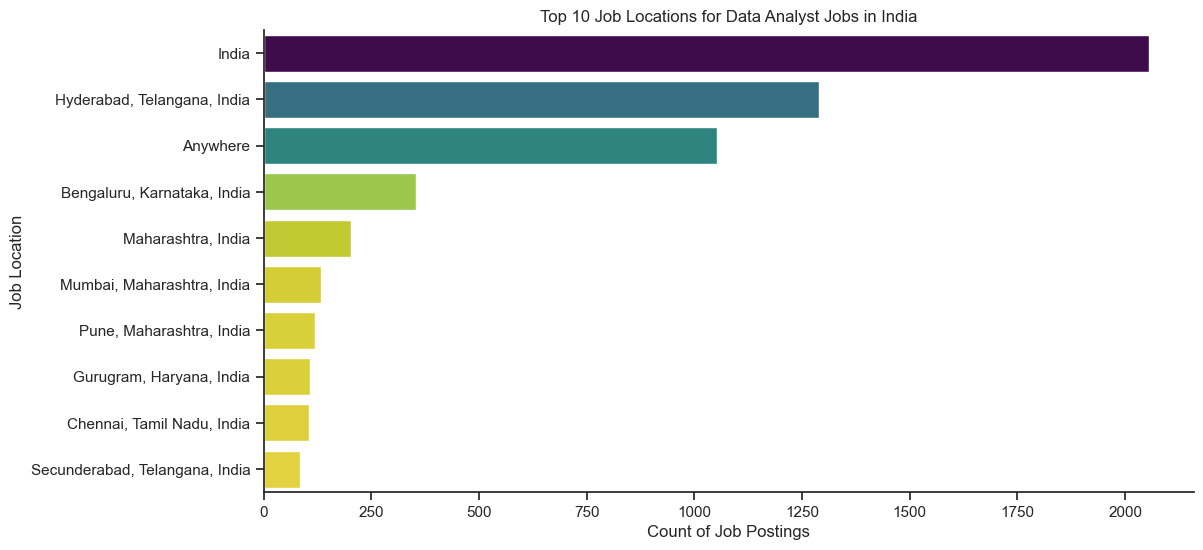

In [35]:
# Displaying the count of job locations for Data Analyst jobs in India
df_locations = df_DA_India['job_location'].value_counts().head(10).to_frame()

# Plotting the distribution of job locations for Data Analyst jobs in India
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_locations, x='count', y='job_location', hue='count', palette='viridis_r', legend=False, ax=ax)
sns.set_theme(style="ticks")
sns.despine()
plt.title('Top 10 Job Locations for Data Analyst Jobs in India')
plt.xlabel('Count of Job Postings')
plt.ylabel('Job Location')
plt.show()

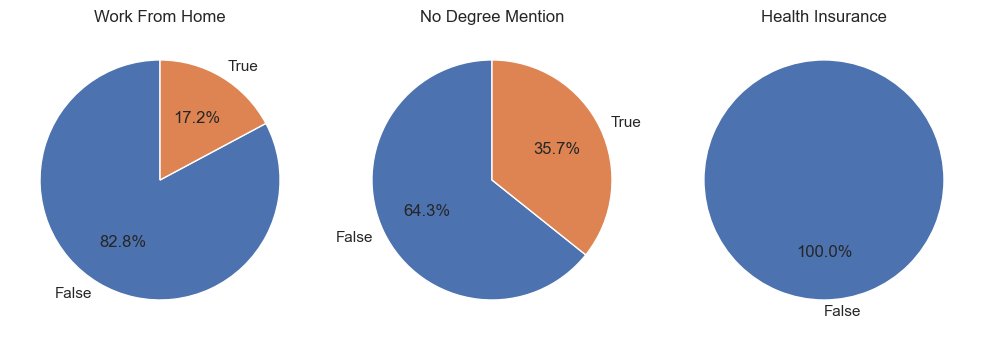

In [44]:
fig, ax = plt.subplots(1, 3,figsize=(10, 6))

dict_coulumn = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance'
}

for i, (column, title) in enumerate(dict_coulumn.items()):
    ax[i].pie(df_DA_India[column].value_counts(), labels=df_DA_India[column].value_counts().index, autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.tight_layout()
plt.show()

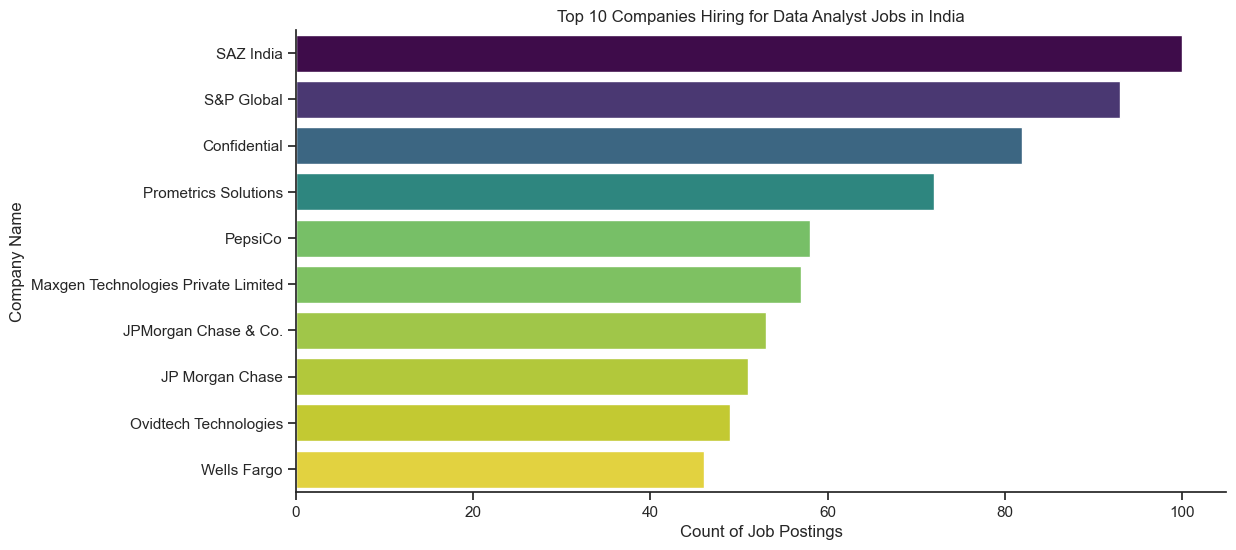

In [34]:
# Displaying the count of companies hiring for Data Analyst jobs in India
df_companies = df_DA_India['company_name'].value_counts().head(10).to_frame()

# Plotting the distribution of companies hiring for Data Analyst jobs in India
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_companies, x='count', y='company_name', hue='count', palette='viridis_r', legend=False, ax=ax)
sns.set_theme(style="ticks")
sns.despine()
plt.title('Top 10 Companies Hiring for Data Analyst Jobs in India')
plt.xlabel('Count of Job Postings')
plt.ylabel('Company Name')
plt.show()